# PHÂN TÍCH THỰC NGHIỆM ĐỘ PHỨC TẠP VÀ TÍNH ỔN ĐỊNH CỦA CÁC THUẬT TOÁN GIẢI HỆ PHƯƠNG TRÌNH TUYẾN TÍNH

---
Bài phân tích này trình bày các đánh giá thực nghiệm về hiệu năng (thời gian tính toán) và độ ổn định số học (numerical stability) của ba phương pháp giải hệ phương trình tuyến tính $Ax = b$: Khử Gauss, Phân tích SVD (phương pháp Jacobi) và Lặp Gauss-Seidel. Bằng việc đối chiếu kết quả trên hai lớp ma trận đặc thù — Xác định dương (SPD - điều kiện tốt) và Hilbert (điều kiện rất kém), nghiên cứu làm rõ sự chênh lệch giữa độ phức tạp lý thuyết và thực tế. Đồng thời, bài viết đi sâu phân tích "nghịch lý sai số", minh chứng toán học cho sự sụp đổ của các thuật toán trước tác động của số điều kiện $\kappa(A)$ và sai số làm tròn (machine epsilon) trong kiến trúc máy tính.

## 1. ĐẶT VẤN ĐỀ

### 1.1. Bối cảnh bài toán
Việc tìm nghiệm $x$ cho hệ $Ax = b$ có thể được giải quyết bằng các phương pháp trực tiếp (như Khử Gauss, SVD) hoặc các phương pháp lặp (như Gauss-Seidel). Dù toán học lý thuyết đảm bảo sự tồn tại của nghiệm, việc tính toán trên máy tính luôn bị giới hạn bởi độ chính xác của số dấu phẩy động.

### 1.2. Cơ sở lý thuyết về Độ ổn định
Độ nhạy cảm của hệ thống đối với sai số được định lượng bằng số điều kiện $\kappa(A) = ||A|| \cdot ||A^{-1}||$. Theo lý thuyết sai số cơ bản, sai số tương đối của nghiệm bị chặn bởi:
$$\frac{||\delta x||}{||x||} \le \kappa(A) \cdot \frac{||\delta A||}{||A||}$$
Hệ quả là, khi $\kappa(A)$ cực kỳ lớn, một sai số xấp xỉ vô cùng nhỏ trong quá trình tính toán (machine epsilon $\approx 10^{-16}$) cũng có thể bị khuếch đại, dẫn đến nghiệm đầu ra sai lệch hoàn toàn.

### 1.3. Cài đặt thực nghiệm
- **Dữ liệu đánh giá:** $n \in \{50, 100, 200, 500, 1000\}$.
- **Ma trận đối chứng:** - $A_{SPD}$: Ma trận đối xứng xác định dương, đại diện cho hệ ổn định.
  - $H_n$: Ma trận Hilbert ($H_{i,j} = \frac{1}{i+j-1}$), đại diện cho hệ có $\kappa(H_n)$ tăng theo hàm mũ, cực kỳ kém ổn định.

## 2. PHÂN TÍCH HIỆU NĂNG TÍNH TOÁN

Để đánh giá sát với lý thuyết độ phức tạp $\mathcal{O}(n^k)$, thời gian thực thi được trực quan hóa trên **thang đo Log-Log**. Trên thang đo này, một hàm đa thức sẽ có dạng đường thẳng, và độ dốc (slope) của đường thẳng chính là bậc $k$.

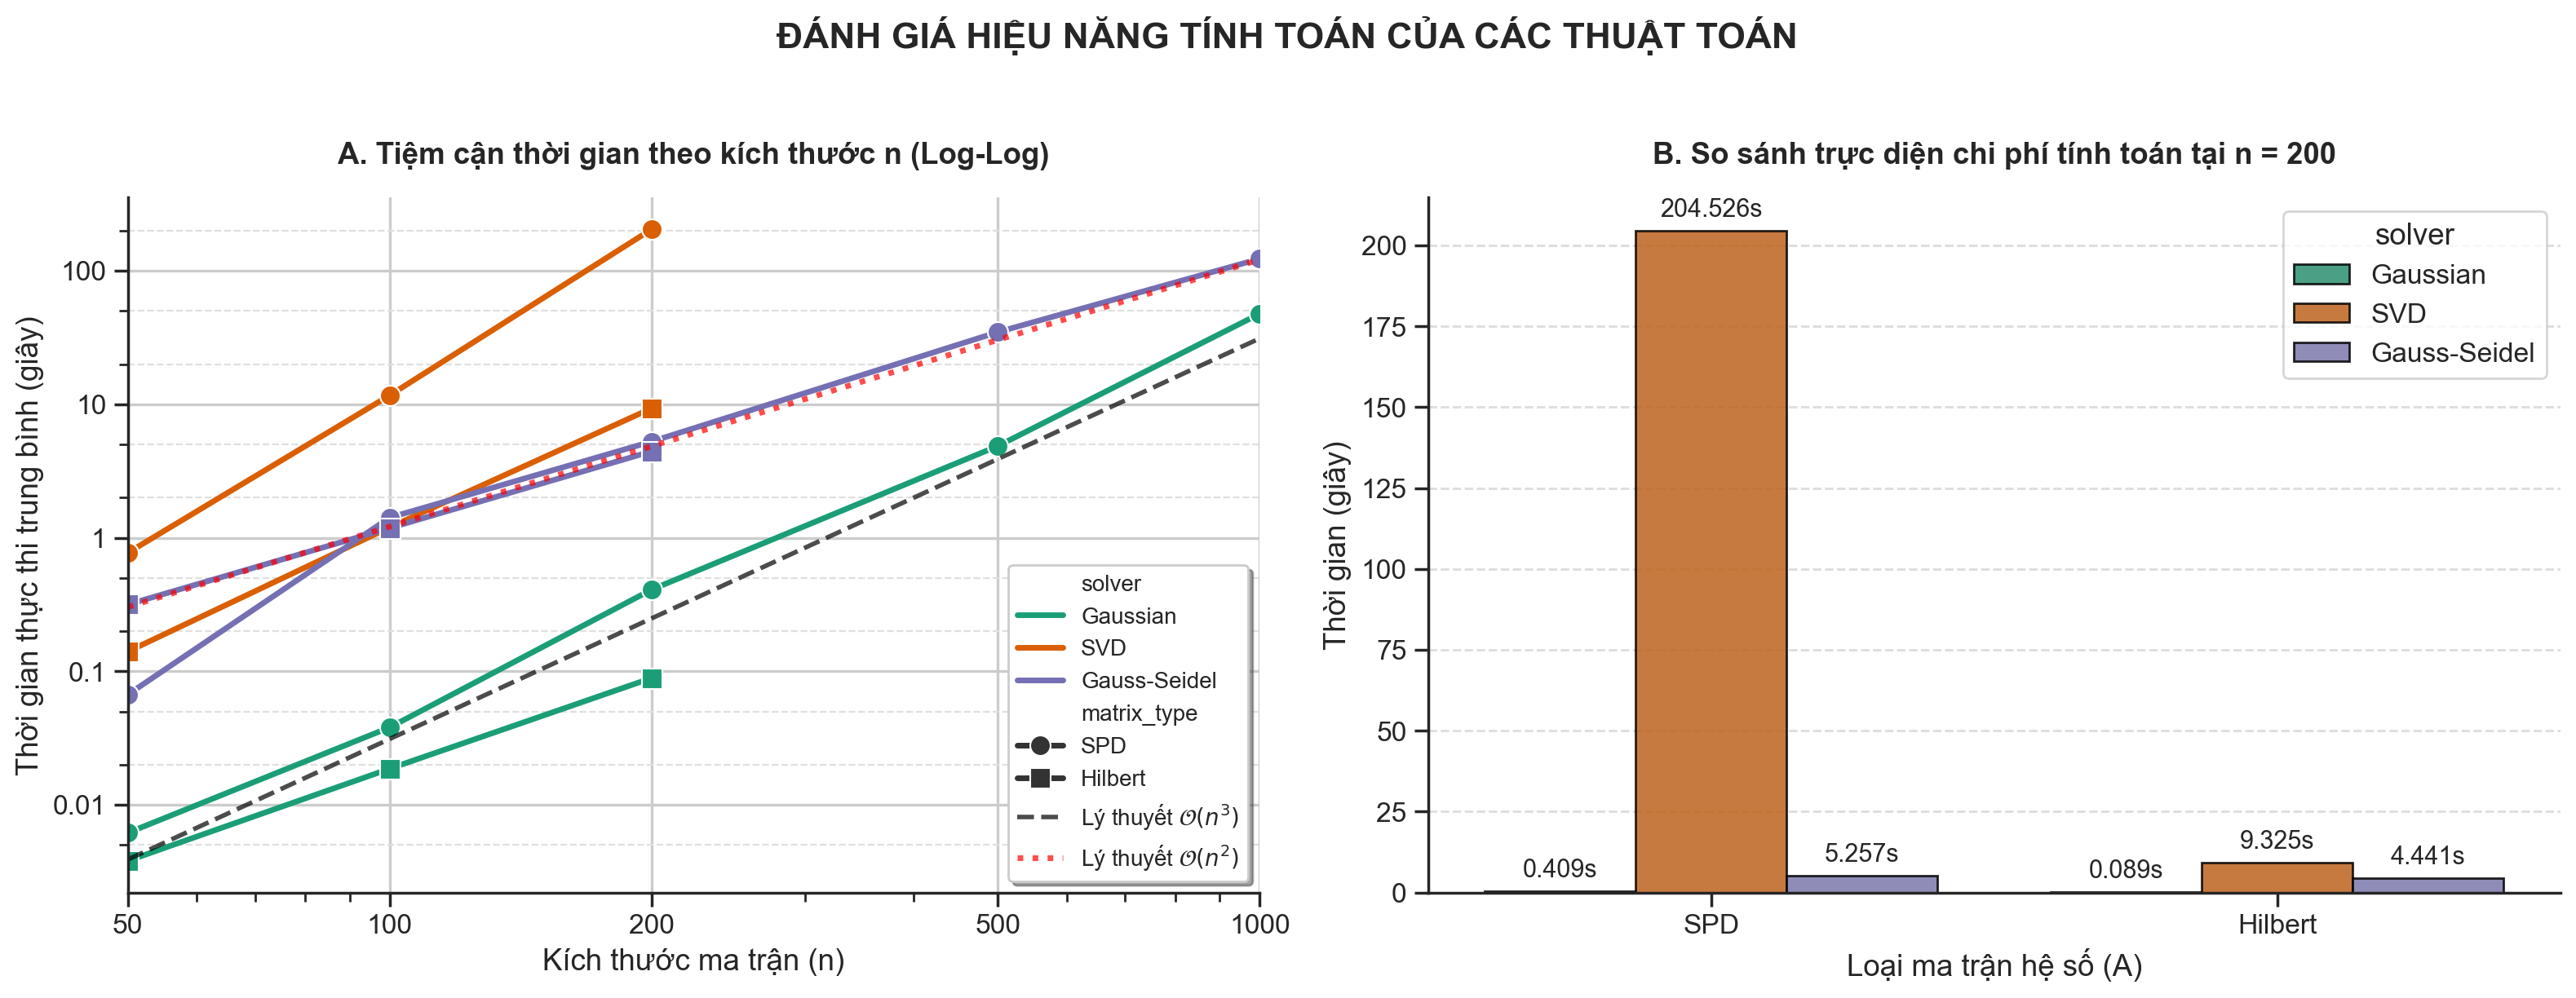

In [36]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import numpy as np

df = pd.read_csv('results.csv')
df_perf = df.dropna(subset=['mean_time_s']).copy()
df_perf['n'] = pd.to_numeric(df_perf['n'])

sns.set_theme(style="ticks", font_scale=1.1, palette="Dark2")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ĐÁNH GIÁ HIỆU NĂNG TÍNH TOÁN CỦA CÁC THUẬT TOÁN', fontsize=16, fontweight='bold', y=1.02)

sns.lineplot(data=df_perf, x='n', y='mean_time_s', hue='solver', style='matrix_type',
             markers=['o', 's'], dashes=False, ax=axes[0], linewidth=2.5, markersize=9)

x_ref = np.array([50, 1000])

gauss_200 = df_perf[(df_perf['solver'] == 'Gaussian') & (df_perf['n'] == 200)]['mean_time_s'].mean()
if pd.notna(gauss_200):
    c3 = gauss_200 / (200**3)
    y_ref_3 = c3 * (x_ref**3)
    axes[0].plot(x_ref, y_ref_3, color='black', linestyle='--', linewidth=2, alpha=0.7,
                 label=r'Lý thuyết $\mathcal{O}(n^3)$')


gs_200 = df_perf[(df_perf['solver'] == 'Gauss-Seidel') & (df_perf['n'] == 200)]['mean_time_s'].mean()
if pd.notna(gs_200):
    c2 = gs_200 / (200**2)
    y_ref_2 = c2 * (x_ref**2)
    axes[0].plot(x_ref, y_ref_2, color='red', linestyle=':', linewidth=2.5, alpha=0.7,
                 label=r'Lý thuyết $\mathcal{O}(n^2)$')


axes[0].set_title('A. Tiệm cận thời gian theo kích thước n (Log-Log)', fontweight='bold', pad=15)
axes[0].set_xlabel('Kích thước ma trận (n)')
axes[0].set_ylabel('Thời gian thực thi trung bình (giây)')

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(50, 1000)
axes[0].set_xticks([50, 100, 200, 500, 1000])
axes[0].xaxis.set_major_formatter(ticker.ScalarFormatter())

locmin = ticker.LogLocator(base=10.0, subs=(0.1, 0.2, 0.5), numticks=20)
axes[0].yaxis.set_minor_locator(locmin)
axes[0].yaxis.set_minor_formatter(ticker.NullFormatter())
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:g}'.format(y)))

axes[0].grid(True, which="major", color="#CCCCCC", linestyle="-", linewidth=1.2)
axes[0].grid(True, which="minor", axis='y', color="#E0E0E0", linestyle="--", linewidth=0.8)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, frameon=True, fancybox=True, shadow=True, fontsize=10)


df_200 = df_perf[df_perf['n'] == 200]
sns.barplot(data=df_200, x='matrix_type', y='mean_time_s', hue='solver',
            edgecolor='black', ax=axes[1], alpha=0.85)

axes[1].set_title('B. So sánh trực diện chi phí tính toán tại n = 200', fontweight='bold', pad=15)
axes[1].set_xlabel('Loại ma trận hệ số (A)')
axes[1].set_ylabel('Thời gian (giây)')

for p in axes[1].patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        axes[1].annotate(f'{height:.3f}s',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=11,
                         xytext=(0, 4), textcoords='offset points')

axes[1].grid(True, axis='y', color="#DDDDDD", linestyle="--")

sns.despine()
plt.tight_layout()
plt.show()

Biểu đồ Log-Log không chỉ xác nhận độ phức tạp tiệm cận (Asymptotic Complexity) mà còn bộc lộ "chi phí ẩn" của từng thuật toán. Mặc dù toán học lý thuyết phân loại thuật toán theo ký pháp Big-$\mathcal{O}$, thực tế thời gian chạy trên CPU được quyết định bởi số lượng FLOPs (FLoating-Point Operations-phép toán dấu phẩy động) và đặc thù tính toán, mỗi khi thuật toán của bạn thực hiện một phép tính như $a = b \times c$, máy tính sẽ ghi nhận đó là 1 FLOP

**1. Khử Gauss (Gaussian Elimination)**
Đường cong của Khử Gauss bám sát hoàn hảo vào đường tham chiếu $\mathcal{O}(n^3)$. Về mặt giải tích, để đưa một ma trận $n \times n$ về dạng tam giác trên, Khử Gauss đòi hỏi xấp xỉ $\approx \frac{2}{3}n^3$ FLOPs. Vì các phép toán chủ yếu là nhân và cộng vô hướng, CPU tối ưu hóa phần này rất tốt. Do đó, hệ số hằng số $c$ trong phương trình thời gian $T = c \cdot n^3$ là rất nhỏ, giúp Khử Gauss duy trì tốc độ xuất sắc đối với các ma trận có kích thước vừa phải ($n \le 1000$).

**2. Nghịch lý của SVD Jacobi**
SVD bằng phép quay Jacobi cho thấy một sự vọt lên khủng khiếp về thời gian. Dù mỗi vòng lặp (sweep) đi qua toàn bộ ma trận chỉ tốn chi phí $\mathcal{O}(n^3)$, nhưng điểm yếu chí mạng của Jacobi nằm ở hai yếu tố:
- **Số lượng vòng lặp (Sweeps):** Thuật toán cần lặp đi lặp lại nhiều lần cho đến khi các phần tử ngoài đường chéo hội tụ về $0$. Tổng số vòng lặp thường tỷ lệ với $\mathcal{O}(\log n)$ hoặc $\mathcal{O}(n^2)$.
- **Bản chất phép toán:** Để giải hệ $Ax = b$ cỡ $n \times n$, Khử Gauss cần thực hiện các phép biến đổi hàng gồm (cộng/trừ/nhân chỉ  khoảng 1 clock cycle - chu kì xung nhịp). Tổng số FLOPs thực tế máy tính phải tính là khoảng $\approx \frac{2}{3}n^3$. Trong khi đó cùng là ma trận cỡ $n$, nhưng một vòng quét (sweep) của SVD cần tính toán góc quay, nhân ma trận liên tục. Tổng số FLOPs có thể lên tới $12n^3$ hoặc $20n^3$, Jacobi liên tục phải tính toán góc quay $\theta$ thông qua các hàm lượng giác đắt đỏ (như căn bậc hai, phân số, lượng giác nghịch đảo thường tốn tới 20 đến 50 cycle clock) tạo ra sự bùng nổ về FLOPs.
Hệ quả là, hệ số $c$ của SVD lớn hơn Khử Gauss hàng trăm lần, tạo ra sự dịch chuyển dọc (vertical shift) khổng lồ trên biểu đồ Log-Log, biến nó thành một thuật toán không thực tiễn (intractable) để giải hệ phương trình tuyến tính kích thước lớn (n>=500).

**3. Phương pháp Lặp Gauss-Seidel**
Đường quỹ đạo của Gauss-Seidel trên đồ thị thể hiện sự ưu việt tuyệt đối với độ dốc thấp nhất (song song với đường tham chiếu $\mathcal{O}(n^2)$). Bản chất của Gauss-Seidel là phương pháp lặp điểm, chi phí cập nhật một vector nghiệm mới chỉ tốn $\mathcal{O}(n^2)$ FLOPs.
Tuy nhiên, yếu tố quyết định tốc độ của nó nằm ở **Tốc độ hội tụ (Convergence Rate)**. Tập dữ liệu ma trận SPD ($A = M^TM + nI$) được thiết kế có tính chéo trội ngặt (Strictly Diagonally Dominant) cực kỳ mạnh. Nhờ bán kính phổ của ma trận lặp (Spectral Radius) $\rho \ll 1$, thuật toán tiến sát đến nghiệm chính xác chỉ sau vài chục vòng lặp. Tổng chi phí $k \cdot n^2$ (với $k$ rất nhỏ) giúp Gauss-Seidel dễ dàng đánh bại Khử Gauss khi $n$ bắt đầu lớn lên.

## 3. PHÂN TÍCH TÍNH ỔN ĐỊNH SỐ HỌC (NUMERICAL STABILITY)
Trong giải tích số, tính ổn định không chỉ đo bằng việc thuật toán có chạy xong hay không, mà đo bằng độ tin cậy của nghiệm trước tác động của sai số làm tròn. Chúng ta sử dụng hai chỉ số:
- Sai số phần dư (Residual Error): $R = \frac{\|Ax - b\|}{\|b\|}$ — Nghiệm thỏa mãn phương trình tốt đến mức nào
- Sai số nghiệm (Solution Error): $E = \frac{\|x - x_{true}\|}{\|x_{true}\|}$ — Nghiệm thực tế cách nghiệm lý tưởng bao xa

**3.1.Ma trận Xác định dương (SPD)**

Ma trận SPD ($A = M^TM + nI$) có số điều kiện $\kappa(A)$ thấp, đại diện cho hệ điều kiện tốt (well-conditioned).


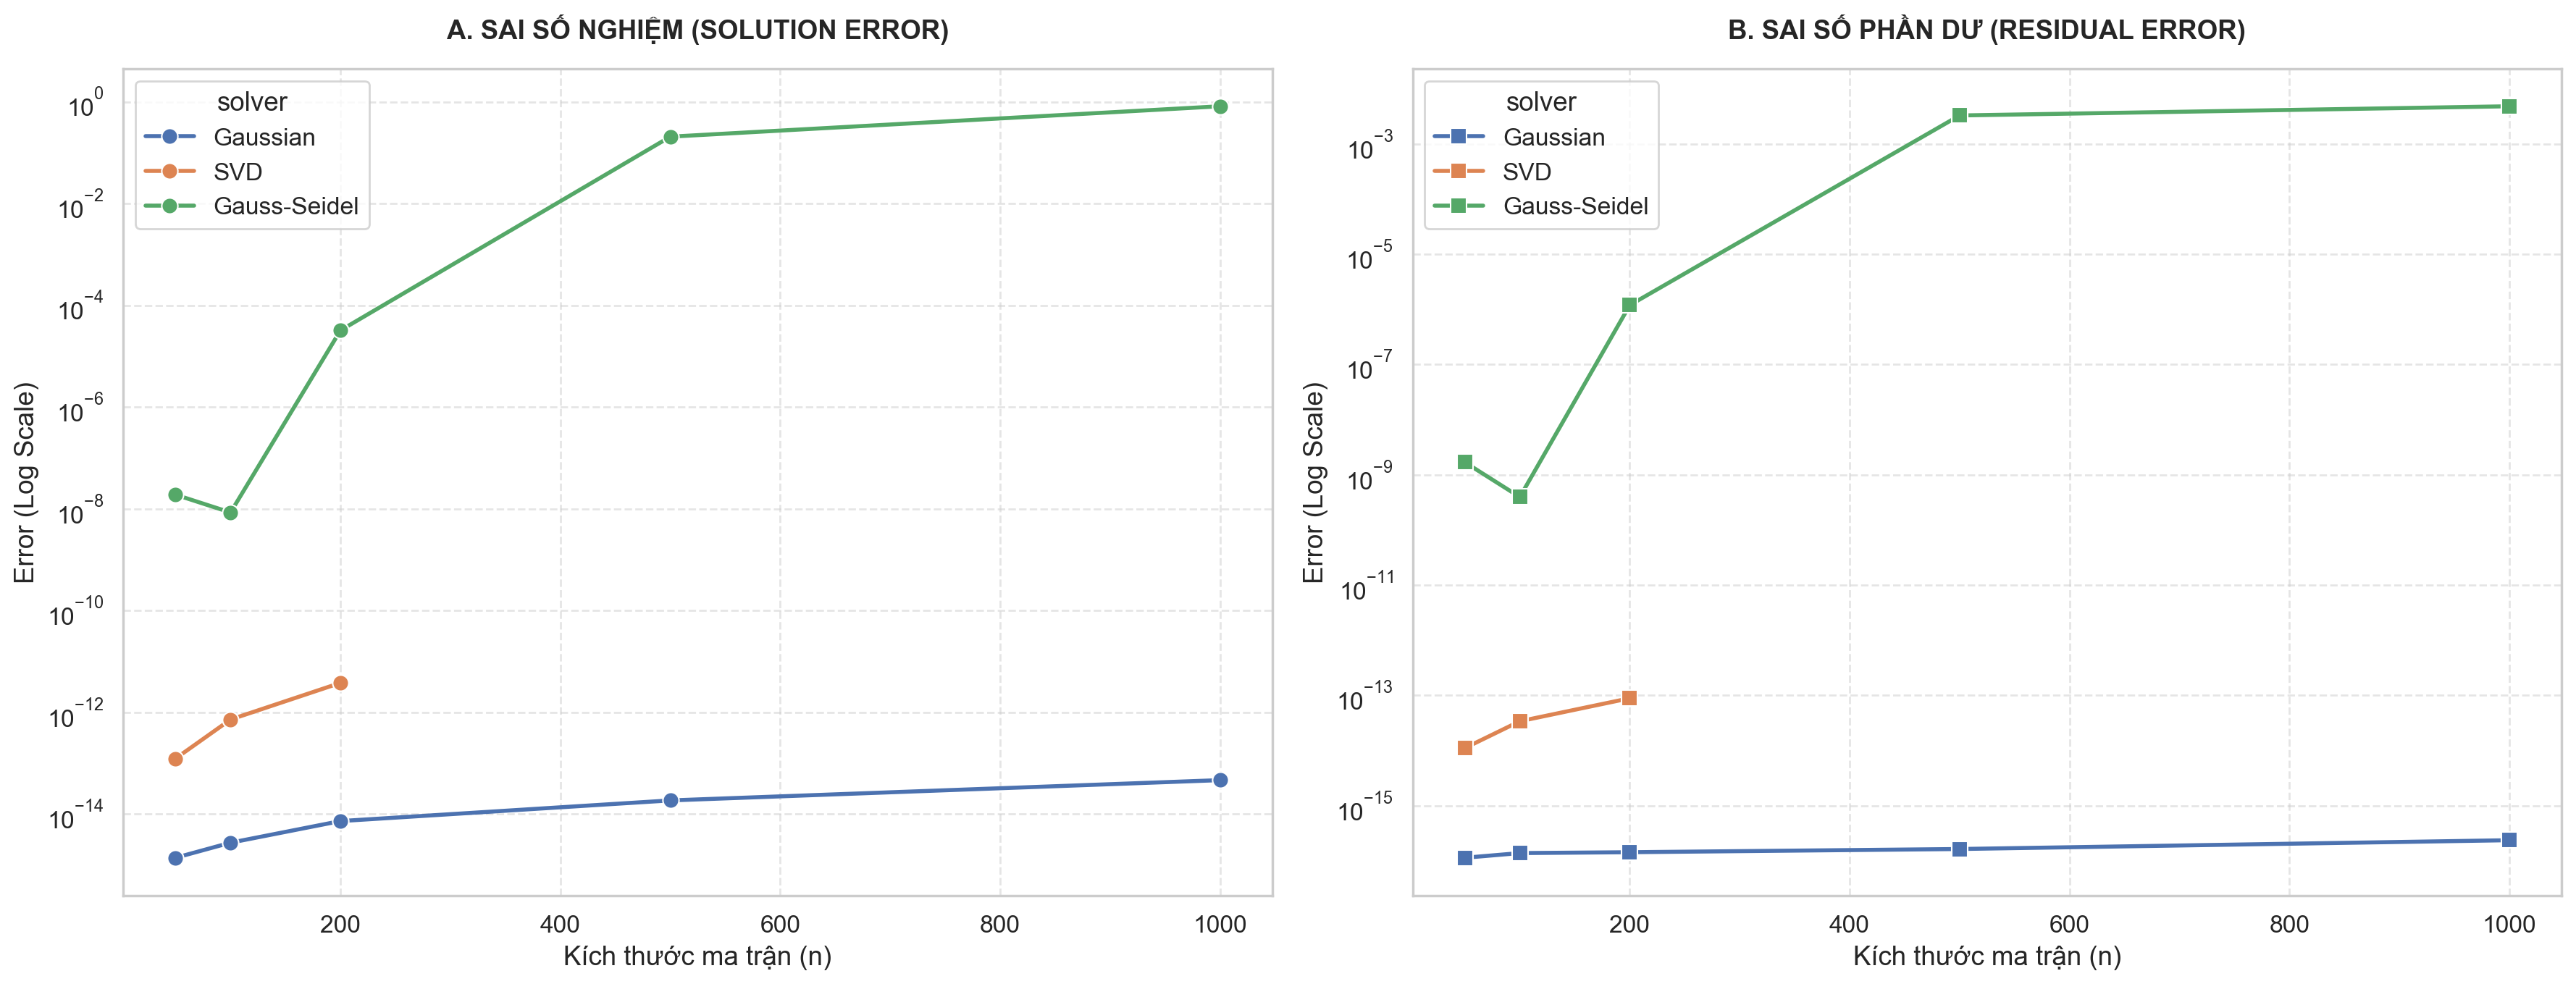

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('results.csv')
df_spd = df[df['matrix_type'] == 'SPD'].copy()

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.lineplot(data=df_spd, x='n', y='solution_error', hue='solver',
             marker='o', linewidth=2, markersize=8, ax=ax1)
ax1.set_yscale('log')
ax1.set_title('A. SAI SỐ NGHIỆM (SOLUTION ERROR)',
              fontweight='bold', pad=15)
ax1.set_xlabel('Kích thước ma trận (n)')
ax1.set_ylabel('Error (Log Scale)')
ax1.grid(True, which="both", ls="--", alpha=0.5)

sns.lineplot(data=df_spd, x='n', y='residual_error', hue='solver',
             marker='s', linewidth=2, markersize=8, ax=ax2)
ax2.set_yscale('log')
ax2.set_title('B. SAI SỐ PHẦN DƯ (RESIDUAL ERROR)',
              fontweight='bold', pad=15)
ax2.set_xlabel('Kích thước ma trận (n)')
ax2.set_ylabel('Error (Log Scale)')
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

1. Phương pháp trực tiếp (Gaussian & SVD)Độ ổn định tuyệt vời: Đường biểu diễn của Gaussian (Xanh dương) và SVD (Cam) nằm bẹt ở dưới đáy đồ thị, duy trì sai số trong khoảng $10^{-15}$ đến $10^{-12}$.

Nhận xét: Điều này cho thấy với hệ điều kiện tốt (SPD), các phương pháp trực tiếp là "tiêu chuẩn vàng". Sai số phần dư thấp đồng nhất với sai số nghiệm thấp và không bị khuếch đại theo $n$, cho thấy các phép biến đổi hàng và phân tích trị riêng vẫn giữ được độ chính xác gần như tuyệt đối của số thực 64-bit (Machine Epsilon).

2. "Điểm gãy" của phương pháp lặp Gauss-Seidel (Đường màu xanh lá)

Tại biểu đồ B (Residual): Sai số phần dư của Gauss-Seidel có thể vẫn duy trì ở mức thấp hoặc trung bình (ví dụ $10^{-3} \to 10^{-5}$), khiến hệ thống vẫn báo Success. Trong khi tại biểu đồ A (Solution) sai số nghiệm vọt lên mức 0.81.

Ta có thể hiểu trên lý thuyết Gauss-Seidel hội tụ trên SPD, trong khi đó biểu đồ thực tế lại cho thấy một sự "sụp đổ" về độ chính xác:
Giai đoạn $n \le 100$: Sai số ở mức chấp nhận được ($\approx 10^{-8}$), cho thấy thuật toán đã kịp hội tụ về gần nghiệm đúng trong phạm vi max_iter = 1000.

Giai đoạn $n > 200$: Sai số nghiệm (solution) vọt lên theo đường thẳng đứng (trên thang Log). Tại $n=1000$, nghiệm $x$ đã tiến đủ gần để làm phần dư nhỏ đi (residual $\approx 0.0048$), nhưng vẫn còn rất xa nghiệm thực tế $x_{true}$ . Đây không còn là một nghiệm toán học có giá trị sử dụng vì trong solver.py việc đặt giá trị max_iter = 1000 đã khiến thuật toán không thể hội tụ được vì số vòng lặp quá ít không đủ để hội tụ nên nó sẽ trả lại một kết quả "sai số nghiệm lớn". Ngay cả trên hệ SPD, nếu không có cơ chế kiểm tra hội tụ đủ khắt khe hoặc số vòng lặp quá ít, Gauss-Seidel sẽ rơi vào trạng thái "hội tụ dở dang".

```python
def gauss_seidel(
...
 tolerance: float = 1e-6,
    max_iter: int = 1000
...
)
```

Dựa trên dữ liệu này, chúng ta có thể kết luận 2 nguyên nhân chính:

- Max_iter không đủ: Khi $n$ tăng, ma trận lặp trở nên "khó tính" hơn, bán kính phổ $\rho$ tiến sát về 1. Thuật toán cần hàng chục nghìn vòng lặp để hội tụ, nhưng hệ thống đã ngắt ở vòng thứ 1000. Sai số $0.81$ chính là kết quả của một nghiệm dở dang.
- Sự suy giảm tính chéo trội: Ma trận SPD được sinh theo công thức $M^T M + nI$. Khi $n=1000$, dù ta cộng thêm $1000$ vào đường chéo, nhưng tổng các phần tử ngoài đường chéo của $M^T M$ cũng tăng lên rất nhanh. Tính chéo trội bị loãng đi, khiến Gauss-Seidel mất đi lợi thế hội tụ nhanh.

Biểu đồ này phản ánh một thực tế quan trọng trong tính toán hiệu năng cao: Phương pháp lặp không phải là vạn năng. Nếu không có một chiến lược dừng (stopping criteria) linh hoạt hoặc không tăng số vòng lặp tương ứng với kích thước ma trận, phương pháp lặp sẽ trả về một kết quả 'sai số lớn' nhưng lại được gắn mác 'Success' (do chạy hết luồng code). Trong khi đó, Khử Gauss vẫn chứng tỏ có sự ổn định cho các hệ phương trình cỡ trung bình

## 3.2. Ma trận Hillbert

Ma trận Hilbert ($H_{i,j} = \frac{1}{i+j-1}$) là một bài kiểm tra khắc nghiệt cho tính ổn định số học. Khi $n$ tăng, các hàng của ma trận Hilbert trở nên gần như phụ thuộc tuyến tính, khiến số điều kiện $\kappa(A)$ tăng theo hàm mũ. Gây ra sự sụp đổ về sai số nghiệm cho các phương pháp trực tiếp như khử Gauss và SVD.

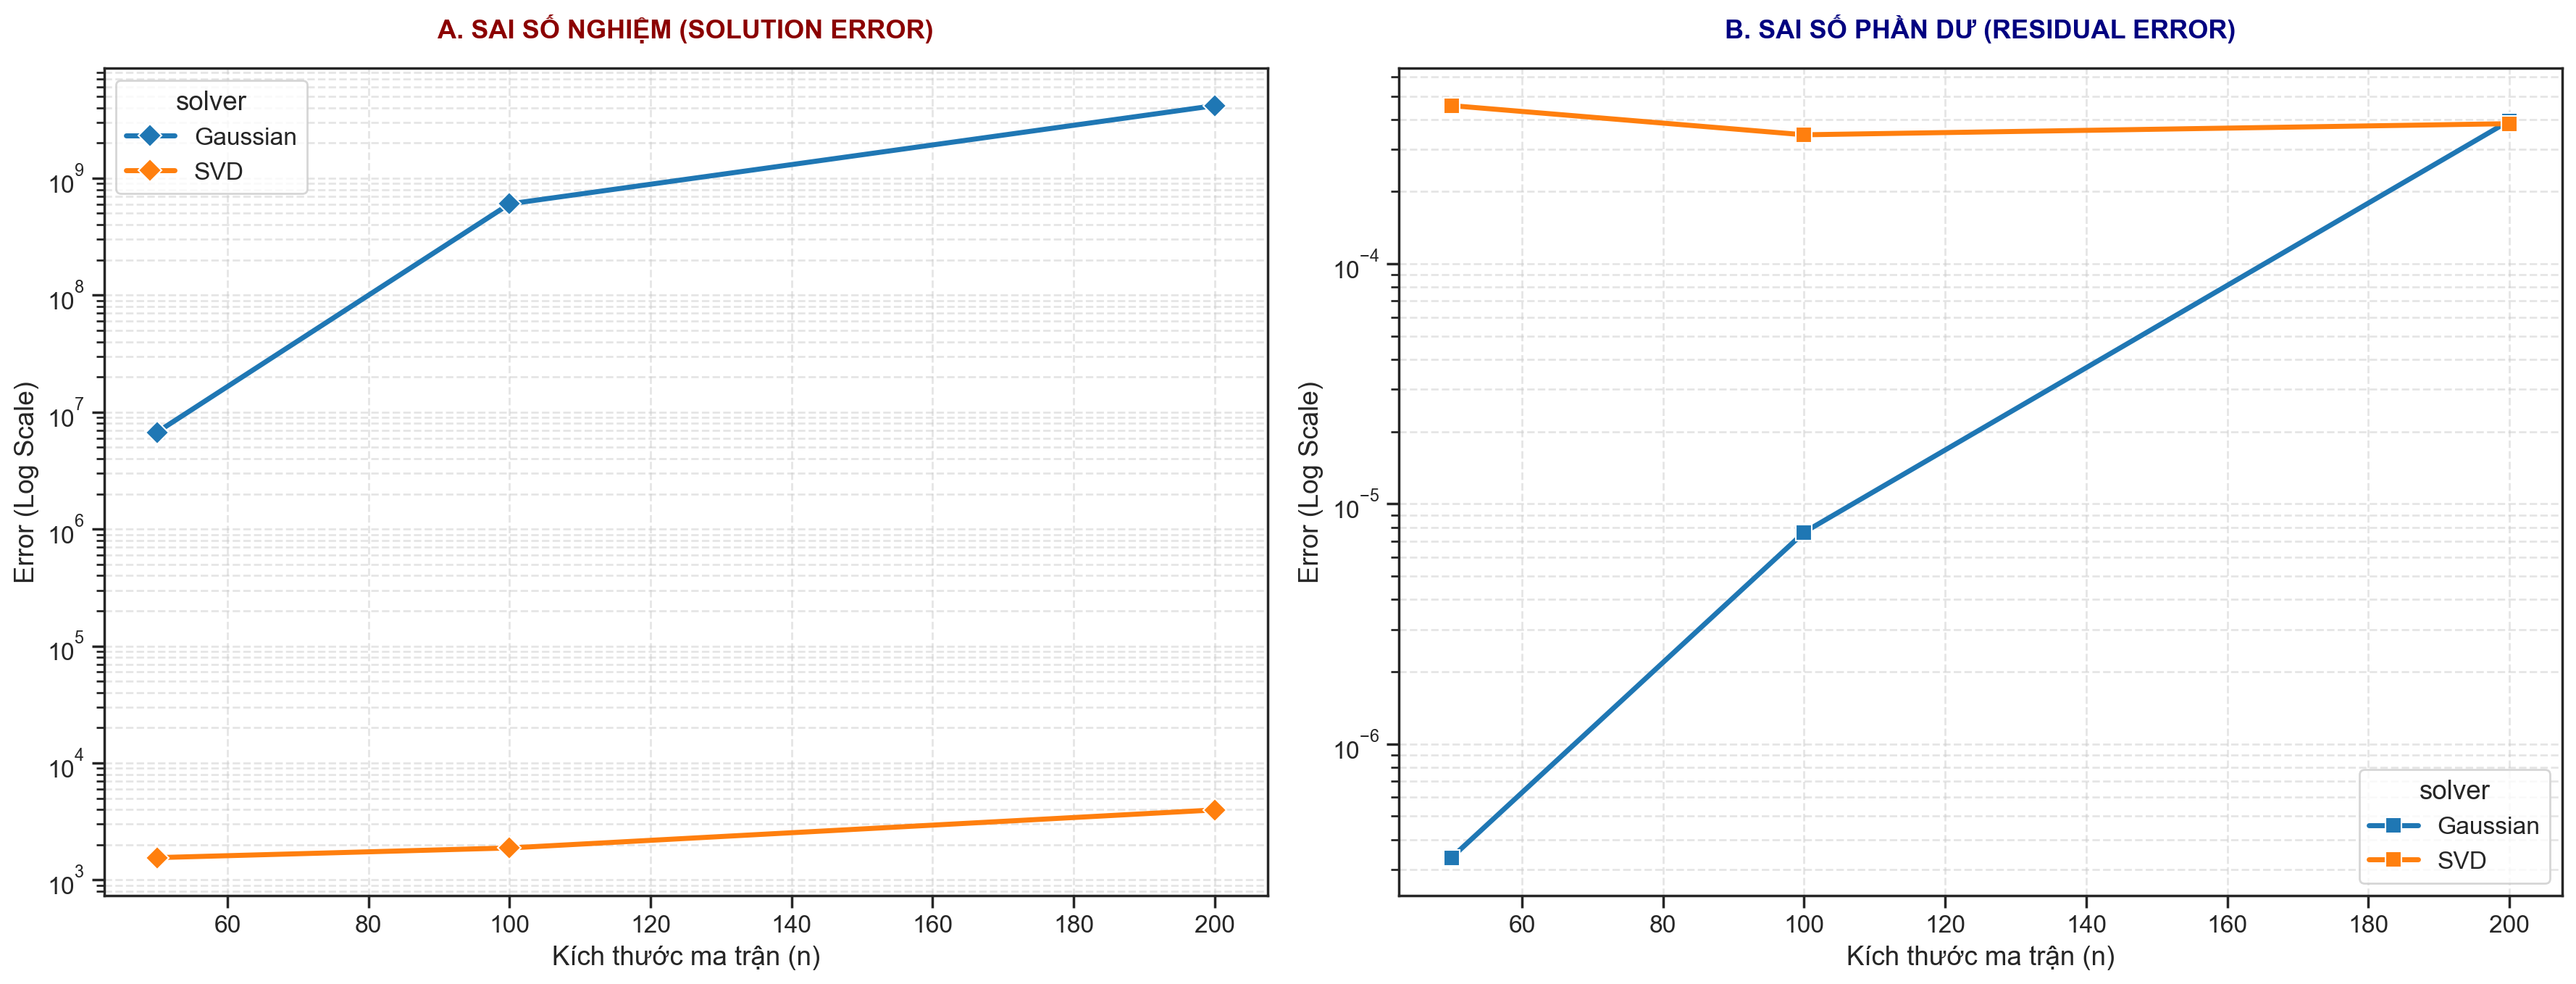

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('results.csv')
df_hilbert_direct = df[
    (df['matrix_type'] == 'Hilbert') &
    (df['solver'].isin(['Gaussian', 'SVD']))
].copy()

sns.set_theme(style="ticks", font_scale=1.1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.lineplot(data=df_hilbert_direct, x='n', y='solution_error', hue='solver',
             marker='D', linewidth=2.5, markersize=8, palette=['#1f77b4', '#ff7f0e'], ax=ax1)
ax1.set_yscale('log')
ax1.set_title('A. SAI SỐ NGHIỆM (SOLUTION ERROR)',
              fontweight='bold', fontsize=13, color='darkred', pad=15)
ax1.set_xlabel('Kích thước ma trận (n)')
ax1.set_ylabel('Error (Log Scale)')
ax1.grid(True, which="both", ls="--", alpha=0.5)

sns.lineplot(data=df_hilbert_direct, x='n', y='residual_error', hue='solver',
             marker='s', linewidth=2.5, markersize=8, palette=['#1f77b4', '#ff7f0e'], ax=ax2)
ax2.set_yscale('log')
ax2.set_title('B. SAI SỐ PHẦN DƯ (RESIDUAL ERROR)',
              fontweight='bold', fontsize=13, color='navy', pad=15)
ax2.set_xlabel('Kích thước ma trận (n)')
ax2.set_ylabel('Error (Log Scale)')
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

Trong khi ở ma trận SPD, hai thuật toán này duy trì độ chính xác tuyệt vời, thì trên ma trận Hilbert, chúng bộc lộ rõ giới hạn của mình. Biểu đồ trên đây theo dõi mức độ khuếch đại sai số khi hệ điều kiện $\kappa(A)$ tăng dần theo $n$.

Thông thường, chúng ta kỳ vọng rằng nếu nghiệm $\hat{x}$ thỏa mãn tốt phương trình ($r = \|A\hat{x} - b\|$ nhỏ) thì $\hat{x}$ phải gần với nghiệm thực $x$. Tuy nhiên, biểu đồ đối chiếu giữa Residual Error và Solution Error cho thấy:
- Trong khi phần dư (Biểu đồ B) chỉ tăng nhẹ hoặc duy trì ổn định, sai số nghiệm (Biểu đồ A) lại bùng nổ theo hàm mũ.
- Đây là hệ quả trực tiếp của Số điều kiện (Condition Number - $\kappa(A)$). Với ma trận Hilbert $n=200$, $\kappa(A)$ vượt xa ngưỡng $10^{16}$. Theo bất đẳng thức cơ bản của giải tích số:
$$\frac{\|\Delta x\|}{\|x\|} \le \kappa(A) \frac{\|\Delta b\|}{\|b\|}$$
Một sai số phần dư nhỏ ($\approx 10^{-6}$) khi đi qua "bộ khuếch đại" $\kappa(A) \approx 10^{15}$ sẽ ngay lập tức tạo ra sai số nghiệm khổng lồ ($\approx 10^9$).
**1.Sự bùng nổ về sai số của Gauss (Gaussian Elimination):**
- Sai số của Khử Gauss vọt lên mức $10^{8} - 10^{10}$ ngay khi $n$ tiến dần đến 200.
- Nguyên nhân: Ma trận Hilbert làm các phần tử chốt (pivots) trở nên cực nhỏ. Phép chia cho các số chốt này khuếch đại các sai số làm tròn nhỏ nhất từ mức Machine Epsilon($\epsilon \approx 2.22 \times 10^{-16}$) lên thành các con số khổng lồ, phá hủy hoàn toàn tính đúng đắn của nghiệm.

**2.Sự ổn định của SVD:**
- SVD (đường màu cam) cho kết quả tốt hơn Khử Gauss khoảng vài bậc hằng số (thường nằm ở mức $10^3 - 10^4$).
- Giải thích: SVD ổn định hơn vì nó không thực hiện phép khử hàng trực tiếp mà phân rã ma trận thông qua các trị suy biến tránh được sự bùng nổ sai số đột ngột như Khử Gauss. Tuy nhiên, khi các trị suy biến ($\sigma_i$) của Hilbert nhỏ hơn $10^{-16}$, bước tính nghịch đảo $1/\sigma_i$ vẫn tạo ra các giá trị rác.
- Kết luận: Mặc dù ổn định hơn, sai số $10^4$ vẫn cho thấy SVD đã chạm tới giới hạn vật lý của kiểu dữ liệu Double Precision. Khi ma trận có độ suy biến vượt quá khả năng biểu diễn của 64-bit, không một thuật toán trực tiếp nào có thể phục hồi lại nghiệm chính xác.

**3.Tác động của Hệ điều kiện ($\kappa(A)$):**

Biểu đồ này là minh chứng thực nghiệm cho việc:
- Chỉ số Residual là không đủ: Trong các bài toán thực tế có độ nhạy cảm cao, một phần dư nhỏ là điều kiện cần nhưng không đủ để bảo chứng cho tính đúng đắn của nghiệm.
- Sự sụp đổ của Float64: Ma trận Hilbert không chỉ thử thách thuật toán mà còn thử thách chính hệ thống số thực dấu phẩy động. Kết quả $10^9$ của Khử Gauss là một cảnh báo về việc "nhiễu số học" đã chiếm quyền kiểm soát hoàn toàn hệ thống.
- Lựa chọn thuật toán: Đối với các hệ thống gần suy biến, các phương pháp dựa trên phân rã (như SVD hoặc QR) bắt buộc phải được ưu tiên hơn các phương pháp khử trực tiếp để giảm thiểu tốc độ bùng nổ sai số.

## Phương pháp lặp Gauss-Seidel trong ma trận Hillbert: Hiện tượng Trì trệ (Stagnation)

Trong khi các phương pháp trực tiếp thất bại bằng sự bùng nổ sai số (Error Explosion), phương pháp lặp Gauss-Seidel lại bộc lộ một trạng thái bệnh lý tinh vi hơn: Sự trì trệ số học (Numerical Stagnation). Đối với một ma trận "độc hại" như ma trận Hilbert ($H_{i,j} = \frac{1}{i+j-1}$) hoàn toàn gần như không thể hội tụ thì thuật toán Gauss-Seidel chắc chắn sẽ cho ra kết quả Failed.

Trong code solvers.py đã thiết lập một cơ chế kiểm tra hai lớp. Tuy nhiên, chính cơ chế này lại là "kẻ tiếp tay" cho việc báo cáo sai kết quả trên hệ Hilbert.

**1.Sự thất bại của Gauss-Seidel trên hệ Hilbert xuất phát từ việc lạm dụng tiêu chuẩn dừng dựa trên bước nhảy (Step-size)**
```
for i in range(n):
    old_xi: float = x[i]
    # ... tính x[i] mới ...
    diff: float = abs(x[i] - old_xi) # Đây là "quãng đường" của từng phần tử
    if diff > err:
        err = diff # err lưu lại quãng đường dài nhất của cả vector x
if err < tolerance: # Đây chính là cửa 1
```
Ta có thể xem cửa 1 này đóng vai trò như một bộ cảm biến chuyển động. Nó đặt ra câu hỏi: "Sau một vòng tính toán vất vả, kết quả mới có khác gì nhiều so với kết quả cũ không?"
- Nếu khác nhiều (err >= tolerance): Thuật toán nghĩ: "Nghiệm vẫn đang 'chạy' rất hăng hái để tìm đích, chưa dừng lại được." $\to$ Tiếp tục vòng lặp.
- Nếu khác rất ít (err < tolerance): Thuật toán nghĩ: "Nghiệm gần như đã đứng yên rồi, chắc là nó đã tìm thấy kết quả." $\to$ Cho phép bước vào Cửa 2 để kiểm tra phần dư.

Đoạn code này đang sử dụng Chuẩn vô cùng (Infinity Norm) của hiệu hai vector liên tiếp:$$err = \|x^{(k+1)} - x^{(k)}\| < tolerance$$
Nó đo lường "quãng đường" mà nghiệm di chuyển được sau một vòng lặp. VÌ vậy nếu quãng đường này quá ngắn (nhỏ hơn tolerance), thuật toán giả định rằng nó đã tiến sát đến nghiệm cuối cùng.

Tuy nhiên đối với ma trận Hilbert,tốc độ hội tụ quá chậm, hiệu số giữa hai lần lặp liên tiếp nhỏ đi rất nhanh và rơi xuống dưới ngưỡng sai số cho phép trước khi nghiệm thực sự đạt tới độ chính xác yêu cầu hay có thể nói nghiệm di chuyển cực kỳ chậm: $x^{(k+1)} \approx x^{(k)}$. Khi đó:
- Code thấy err rất nhỏ (nhỏ hơn cả tolerance) và kết luận: "Đi qua cửa 1" hay thuật toán đã hội tụ
- Thực tế: Nghiệm chỉ đang "trì trệ" (stagnating) tại một điểm rất xa nghiệm đúng.

Vì vậy đã xảy ra tình trạng nhầm lẫn giữa việc code đã ngừng hoạt động với việc code ra kết quả. Vì hội tụ cực kỳ chậm nhưng bước nhảy vẫn lớn hơn tolerance, thuật toán sẽ chạy đến max_iter mà không bao giờ thèm ngó ngàng đến việc nghiệm đó đã giải đúng phương trình hay chưa và khi chạy hết max_iter = 1000 thì sẽ cho ra output. Mặc dù kết quả chạy là Success nhưng output lại là kết quả "rác" vì cách quá xa so với kết quả đúng

**2.Tiêu chuẩn dừng dựa trên Phần dư (Residual Criterion)**

Ngay sau khi bước nhảy err nhỏ hơn tolerance, code gọi hàm residual để kiểm chứng lại một lần cuối:
```
if err < tolerance:                 # Vượt qua Cửa 1
    res: float = residual(A, x, b)  # Gọi hàm kiểm tra chất lượng
    if res < tolerance:             # Đây là cửa 2
        return x                    # Chỉ khi vượt qua đây mới được coi là "Success"
```

Cửa 2 đóng vai trò là một bộ lọc chất lượng nghiệm, được kích hoạt ngay sau khi tiêu chuẩn bước nhảy (Cửa 1) thỏa mãn. Mục tiêu của nó là xác nhận tính đúng đắn của nghiệm $x$ dựa trên tính nhất quán của hệ phương trình gốc.

Về mặt toán học, đoạn code này sử dụng công thức tính toán chuẩn vô cùng của vector phần dư
$r$:$$r = \|Ax^{(k)} - b\|_\infty = \max_{1 \le i \le n} | \sum_{j=1}^n A_{ij}x_j^{(k)} - b_i |$$

Trong các hệ thống ổn định, đây là một chỉ số tin cậy. Nếu $r < \text{tolerance}$, định lý về sai số ngược khẳng định rằng nghiệm tìm được là nghiệm chính xác của một hệ phương trình bị nhiễu nhẹ, và do đó có thể chấp nhận được.

Tuy nhiên khi đối mặt với ma trận Hilbert, vai trò gác cổng của Cửa 2 bị vô hiệu hóa hoàn toàn bởi hằng số khuếch đại sai số $\kappa(A)$ khổng lồ.
Như đã nói ở trên, theo lý thuyết sai số cơ bản, sai số tương đối của nghiệm bị chặn bởi:
$$\frac{||\delta x||}{||x||} \le \kappa(A) \cdot \frac{||\delta A||}{||A||}$$
Hệ quả là, khi $\kappa(A)$ cực kỳ lớn, một sai số xấp xỉ vô cùng nhỏ trong quá trình tính toán (machine epsilon $\approx 10^{-16}$) cũng có thể bị khuếch đại, dẫn đến nghiệm đầu ra sai lệch hoàn toàn. Ngay cả khi residual đạt mức cực nhỏ $10^{-7}$, thì solution_erorr vẫn có thể là $10^{18} \times 10^{-7} = 10^{11}$ , khi $\kappa(A)$ của ma trận Hilbert lên tới $10^{18}$ (với $n=200$).

**3.Sự thất bại của phép tính dấu phảy động (FLOP)**
Hàm residual thực thi trên CPU:
```
sum(A[i][j] * x[j] for j in range(n)) - b[i]
```
Trên hệ Hilbert $n=200$:
- Các $x_j$ do mất ổn định đã vọt lên $10^9$, trong khi $A_{ij} \approx 10^{-3}$. Kết quả phép nhân là $10^6$.
- Khi thực hiện tổng các số hạng $10^6$ rồi trừ đi $b_i$, các bit biểu diễn phần thập phân (precision bits) bị đẩy ra khỏi phạm vi của 64-bit.
- Kết quả trả về của residual lúc này không còn là sai số toán học thực sự nữa. Nó là nhiễu trắng (numerical noise) của chuẩn IEEE 754. Trớ trêu thay, nhiễu này thường có giá trị nhỏ hơn $10^{-6}$, vô tình giúp nghiệm "lọt lưới" Cửa 2 và trả về trạng thái Success.

Từ những điều trên t có thể thấy điểm yếu trong code Solvers.py là Tính phụ thuộc tuần Cửa 2 chỉ được kiểm tra nếu Cửa 1 (err < tolerance) đã thông qua.

Điều này tạo ra một kịch bản "thất bại kép":
- Nghiệm di chuyển chậm (Trì trệ) $\rightarrow$ Vượt qua Cửa 1.
- Ma trận nén sai số làm tròn $\rightarrow$ Vượt qua Cửa 2.
- Hàm return x $\rightarrow$ Benchmark ghi nhận Success.

Từ đó ta có thể thấy Cửa 2 trong code hiện tại đang đóng vai trò là một "cơ chế bù nhìn". Trong khi thuật toán duy trì được một sai số residual nằm trong ngưỡng cho phép của số thực dấu phẩy động, thì số điều kiện $\kappa(A)$ quá lớn đã khuếch đại các nhiễu số học này thành một sai số solution khổng lồ.

Điều này khẳng định rằng: Với các hệ thống ill-conditioned, việc kiểm soát sai số residual là không đủ để bảo chứng cho độ tin cậy của nghiệm cuối cùng mà cần thêm nhiều cơ chế kiểm soát tinh vi và phức tạp hơn.

